In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

In [41]:
df = pd.read_csv(r'C:\Users\mouli\Downloads\Invistico_Airline.csv')
df

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,...,4,2,2,0,2,4,2,5,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,satisfied,Female,disloyal Customer,29,Personal Travel,Eco,1731,5,5,5,...,2,2,3,3,4,4,4,2,0,0.0
129876,dissatisfied,Male,disloyal Customer,63,Personal Travel,Business,2087,2,3,2,...,1,3,2,3,3,1,2,1,174,172.0
129877,dissatisfied,Male,disloyal Customer,69,Personal Travel,Eco,2320,3,0,3,...,2,4,4,3,4,2,3,2,155,163.0
129878,dissatisfied,Male,disloyal Customer,66,Personal Travel,Eco,2450,3,2,3,...,2,3,3,2,3,2,1,2,193,205.0


In [42]:
df.isna().sum()

satisfaction                           0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

In [43]:
df.duplicated().sum()

0

In [44]:
df.dropna(inplace = True)

In [45]:
df.isnull().sum()

satisfaction                         0
Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Seat comfort                         0
Departure/Arrival time convenient    0
Food and drink                       0
Gate location                        0
Inflight wifi service                0
Inflight entertainment               0
Online support                       0
Ease of Online booking               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Cleanliness                          0
Online boarding                      0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
dtype: int64

In [46]:
df.describe()

,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
count,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000
mean,39.428761,1981.008974,2.838586,2.990277,2.852024,2.990377,3.249160,3.383745,3.519967,3.472171,3.465143,3.486118,3.695460,3.340729,3.705886,3.352545,14.643385,15.091129
std,15.117597,1026.884131,1.392873,1.527183,1.443587,1.305917,1.318765,1.345959,1.306326,1.305573,1.270755,1.292079,1.156487,1.260561,1.151683,1.298624,37.932867,38.465650
min,7.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,1359.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,1924.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,0.000000,0.000000
75%,51.000000,2543.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,6951.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [47]:
df['Flight Distance'].nunique()

5397

In [48]:
df['satisfaction'].value_counts()

satisfaction
satisfied       70882
dissatisfied    58605
Name: count, dtype: int64

In [49]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,129487.0,39.428761,15.117597,7.0,27.0,40.0,51.0,85.0
Flight Distance,129487.0,1981.008974,1026.884131,50.0,1359.0,1924.0,2543.0,6951.0
Seat comfort,129487.0,2.838586,1.392873,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,129487.0,2.990277,1.527183,0.0,2.0,3.0,4.0,5.0
Food and drink,129487.0,2.852024,1.443587,0.0,2.0,3.0,4.0,5.0
Gate location,129487.0,2.990377,1.305917,0.0,2.0,3.0,4.0,5.0
Inflight wifi service,129487.0,3.249160,1.318765,0.0,2.0,3.0,4.0,5.0
Inflight entertainment,129487.0,3.383745,1.345959,0.0,2.0,4.0,4.0,5.0
Online support,129487.0,3.519967,1.306326,0.0,3.0,4.0,5.0,5.0
Ease of Online booking,129487.0,3.472171,1.305573,0.0,2.0,4.0,5.0,5.0


In [50]:
df.isnull().sum()

satisfaction                         0
Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Seat comfort                         0
Departure/Arrival time convenient    0
Food and drink                       0
Gate location                        0
Inflight wifi service                0
Inflight entertainment               0
Online support                       0
Ease of Online booking               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Cleanliness                          0
Online boarding                      0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
dtype: int64

# Checking outliers in numerical columns

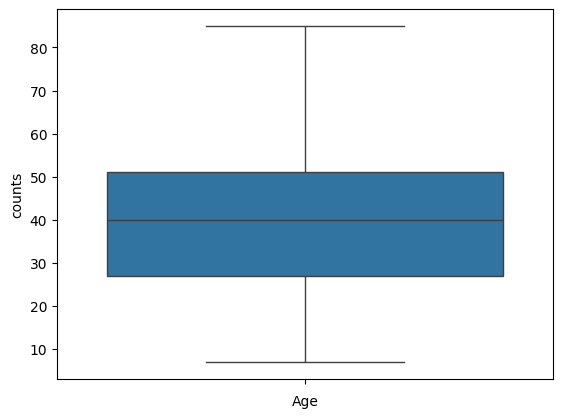

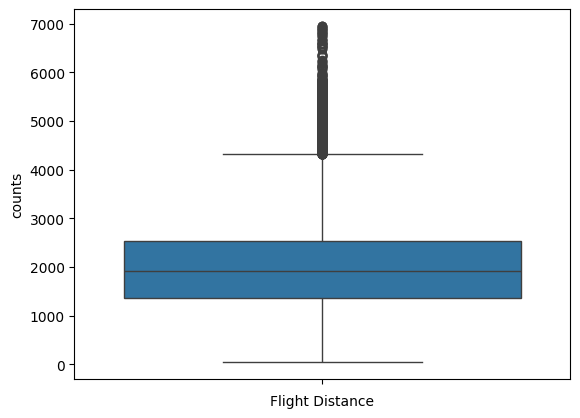

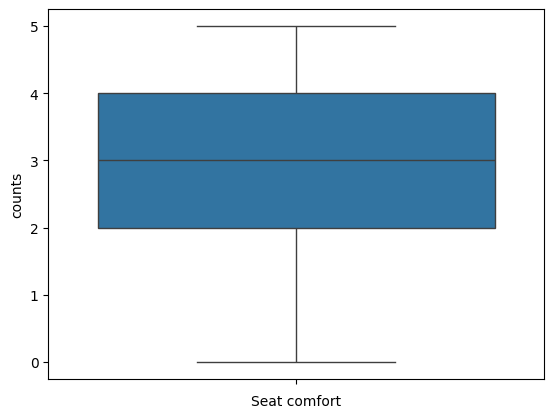

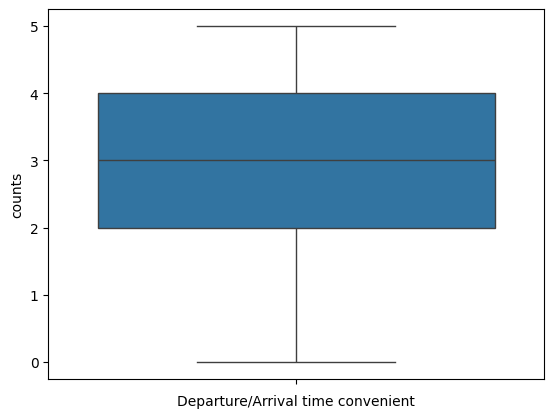

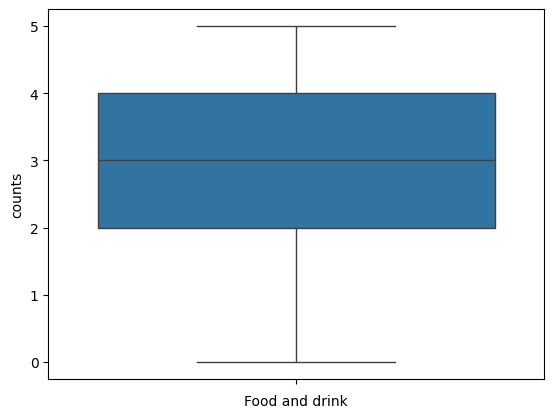

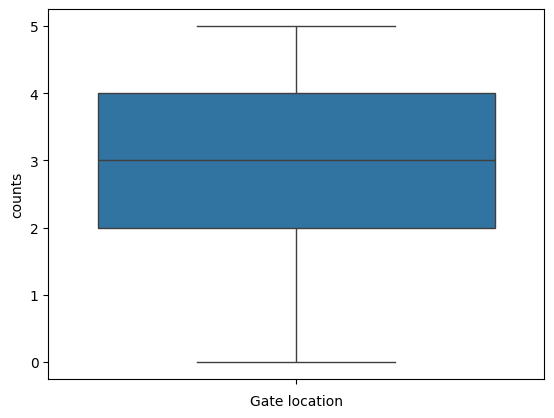

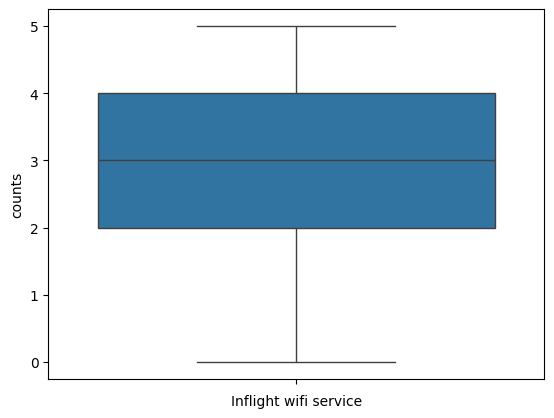

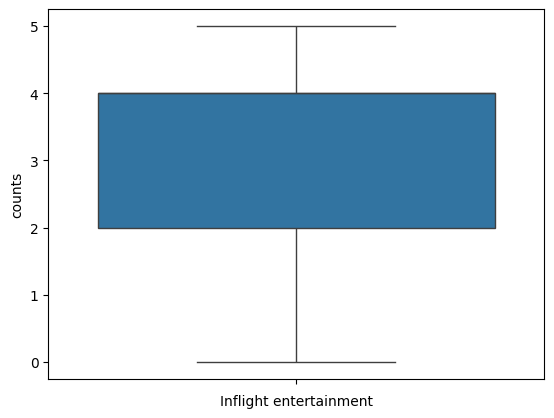

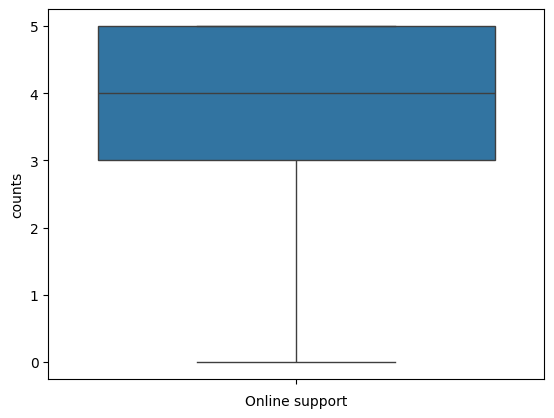

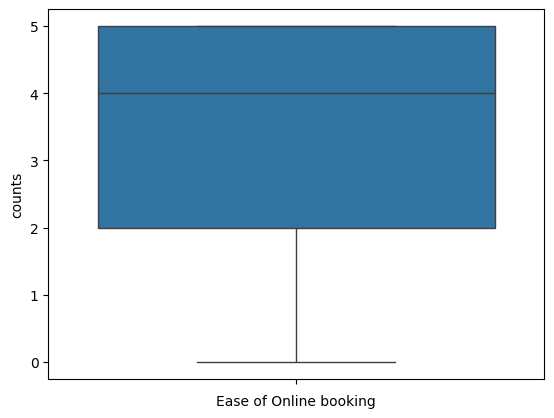

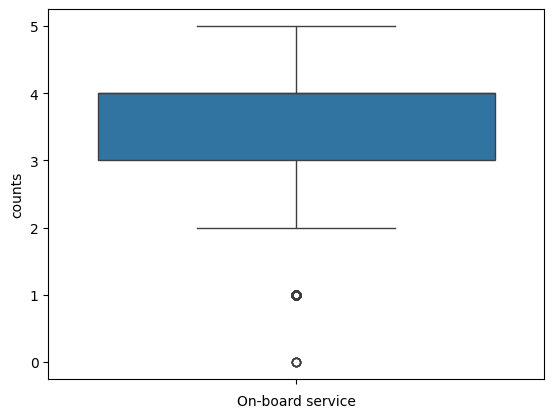

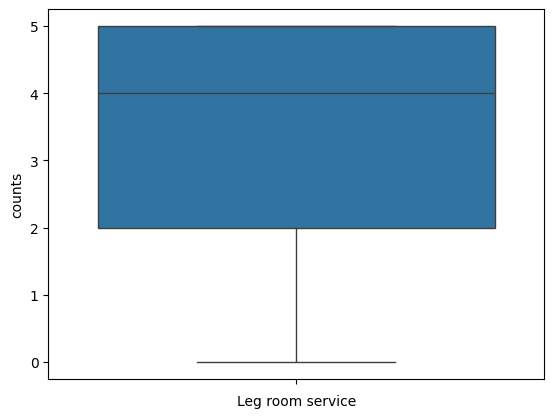

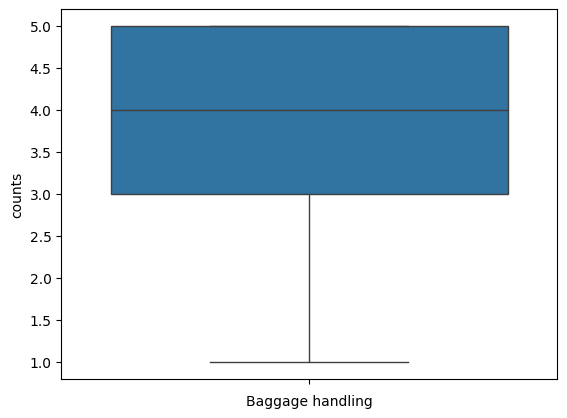

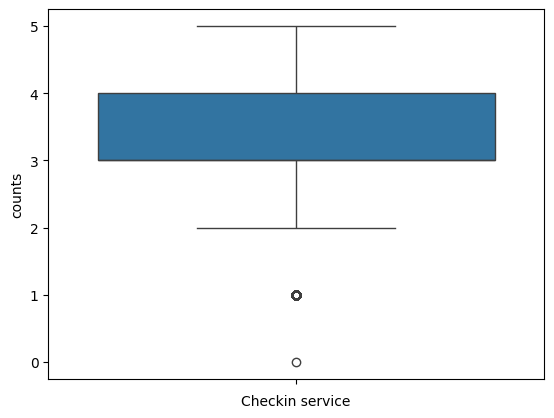

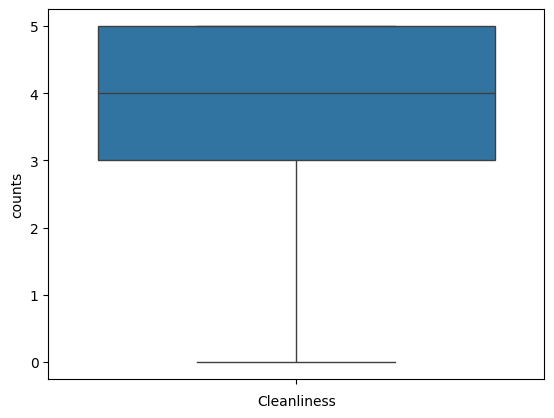

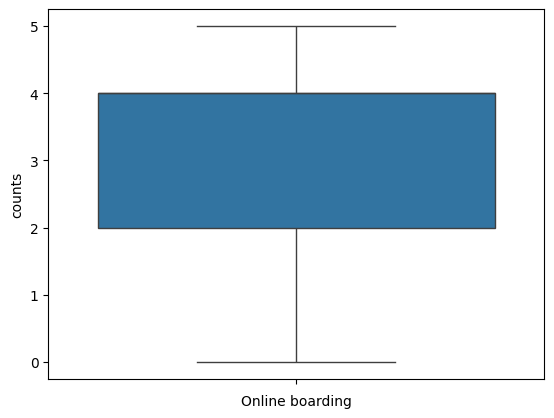

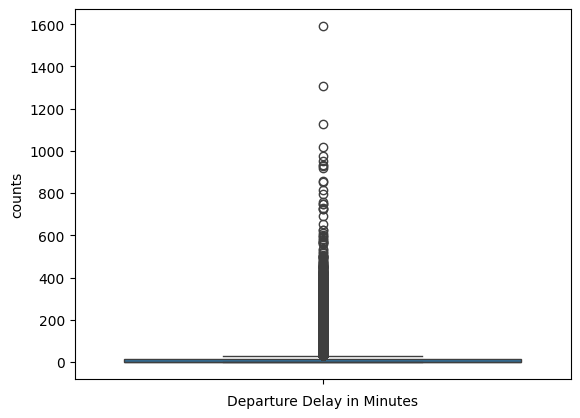

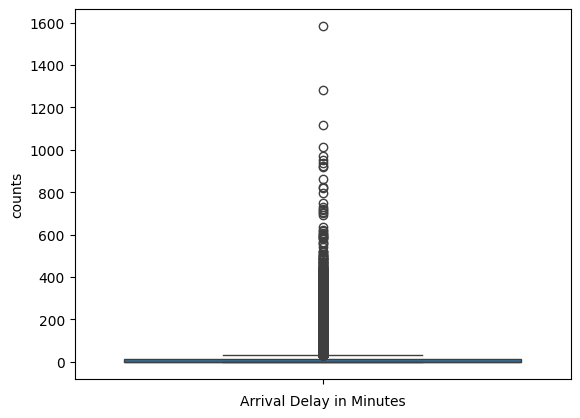

In [51]:
for x in df.columns:
    if df[x].dtype != object:
        sns.boxplot(df[x])
        plt.xlabel(x)
        plt.ylabel('counts')
        plt.show()

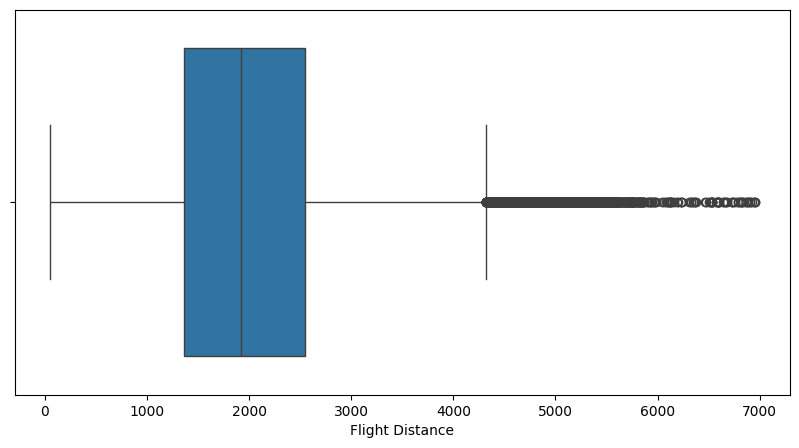

In [52]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['Flight Distance'])
plt.show()

In [53]:
df[['Flight Distance','Departure Delay in Minutes','Arrival Delay in Minutes']].skew()

Flight Distance               0.466459
Departure Delay in Minutes    6.853578
Arrival Delay in Minutes      6.670125
dtype: float64

In [54]:
cols = ['Departure Delay in Minutes', 'Arrival Delay in Minutes']

for col in cols:
    df[col] = np.log1p(df[col])

In [55]:
df[cols]

,Departure Delay in Minutes,Arrival Delay in Minutes
0,0.000000,0.000000
1,5.739793,5.723585
2,0.000000,0.000000
3,0.000000,0.000000
4,0.000000,0.000000
...,...,...
129875,0.000000,0.000000
129876,5.164786,5.153292
129877,5.049856,5.099866
129878,5.267858,5.327876


In [56]:
df[cols].value_counts()

Departure Delay in Minutes  Arrival Delay in Minutes
0.000000                    0.000000                    59351
0.693147                    0.000000                     2475
1.098612                    0.000000                     1796
0.000000                    0.693147                     1492
1.386294                    0.000000                     1462
                                                        ...  
4.532599                    4.584967                        1
                            4.564348                        1
                            4.532599                        1
1.386294                    3.713572                        1
7.373374                    7.368340                        1
Name: count, Length: 8969, dtype: int64

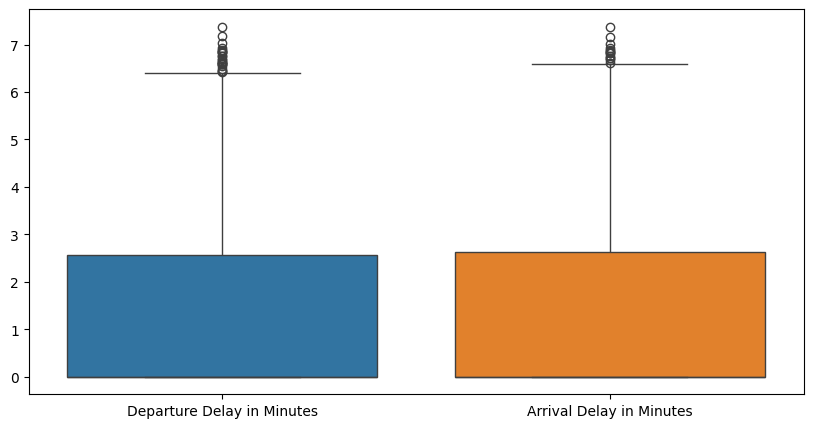

In [57]:
plt.figure(figsize=(10,5))
sns.boxplot(df[cols])
plt.show()

# checking outliers counts of every columns

In [58]:
# Select numeric columns
numeric_cols = df.select_dtypes(include='number')
# Dictionary to store counts
outlier_counts = {}
for col in numeric_cols.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_counts[col] = len(outliers)
# Print counts
for col, count in outlier_counts.items():
    print(f"{col}: {count} outliers")

Age: 0 outliers
Flight Distance: 2575 outliers
Seat comfort: 0 outliers
Departure/Arrival time convenient: 0 outliers
Food and drink: 0 outliers
Gate location: 0 outliers
Inflight wifi service: 0 outliers
Inflight entertainment: 0 outliers
Online support: 0 outliers
Ease of Online booking: 0 outliers
On-board service: 13228 outliers
Leg room service: 0 outliers
Baggage handling: 0 outliers
Checkin service: 15323 outliers
Cleanliness: 0 outliers
Online boarding: 0 outliers
Departure Delay in Minutes: 24 outliers
Arrival Delay in Minutes: 14 outliers


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 129487 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129487 non-null  object 
 1   Gender                             129487 non-null  object 
 2   Customer Type                      129487 non-null  object 
 3   Age                                129487 non-null  int64  
 4   Type of Travel                     129487 non-null  object 
 5   Class                              129487 non-null  object 
 6   Flight Distance                    129487 non-null  int64  
 7   Seat comfort                       129487 non-null  int64  
 8   Departure/Arrival time convenient  129487 non-null  int64  
 9   Food and drink                     129487 non-null  int64  
 10  Gate location                      129487 non-null  int64  
 11  Inflight wifi service              129487 no

In [60]:
df['Type of Travel'].unique()

array(['Personal Travel', 'Business travel'], dtype=object)

In [61]:
df['satisfaction'].unique()

array(['satisfied', 'dissatisfied'], dtype=object)

In [62]:
# for col in df.columns:
#     if df[col].dtype != 'object':
#         df[col] = df[col].apply(np.log1p)
        

# Converting Categorical value into Numerical 

In [63]:
# Binary encoding

In [64]:
df['Gender'] = df['Gender'].map({'Male': 1 , 'Female' : 0 })
df['Customer Type'] = df['Customer Type'].map({'Loyal Customer' : 1, 'disloyal Customer' : 0})
df['Type of Travel'] = df['Type of Travel'].map({'Personal Travel' : 1 , 'Business travel' : 0})

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 129487 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129487 non-null  object 
 1   Gender                             129487 non-null  int64  
 2   Customer Type                      129487 non-null  int64  
 3   Age                                129487 non-null  int64  
 4   Type of Travel                     129487 non-null  int64  
 5   Class                              129487 non-null  object 
 6   Flight Distance                    129487 non-null  int64  
 7   Seat comfort                       129487 non-null  int64  
 8   Departure/Arrival time convenient  129487 non-null  int64  
 9   Food and drink                     129487 non-null  int64  
 10  Gate location                      129487 non-null  int64  
 11  Inflight wifi service              129487 no

In [66]:
df['Class'] = df['Class'].map({'Eco':2 , 'Business':1 , 'Eco Plus' : 0})

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 129487 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129487 non-null  object 
 1   Gender                             129487 non-null  int64  
 2   Customer Type                      129487 non-null  int64  
 3   Age                                129487 non-null  int64  
 4   Type of Travel                     129487 non-null  int64  
 5   Class                              129487 non-null  int64  
 6   Flight Distance                    129487 non-null  int64  
 7   Seat comfort                       129487 non-null  int64  
 8   Departure/Arrival time convenient  129487 non-null  int64  
 9   Food and drink                     129487 non-null  int64  
 10  Gate location                      129487 non-null  int64  
 11  Inflight wifi service              129487 no

In [68]:
df['satisfaction'] = df['satisfaction'].map({'satisfied' : 1, 'dissatisfied': 0})

In [69]:
df['satisfaction'].value_counts()

satisfaction
1    70882
0    58605
Name: count, dtype: int64

In [89]:
X = df.drop('satisfaction',axis=1)
y = df['satisfaction']

In [90]:
print(X.shape)
print(y.shape)

(129487, 22)
(129487,)


In [91]:
x_train , x_test ,y_train , y_test = train_test_split(X,y, random_state = 100 , test_size = 0.20)

In [92]:
model = LogisticRegression(max_iter=1000, solver='saga')
model.fit(x_train , y_train)

C:\python ny inteelipat\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(max_iter=1000, solver='saga')

In [93]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(x_train, y_train)



In [94]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X_train = scaler.fit_transform(x_train)
# X_test = scaler.transform(x_test)

In [95]:
y_pred = rf.predict(x_test)
y_pred

array([0, 0, 0, ..., 1, 0, 0], dtype=int64)

In [96]:
accuracy_score(y_test, y_pred)

0.9566761912116766

In [97]:
print(y_pred[:10])

[0 0 0 1 1 0 0 0 1 0]


In [79]:
precision_score(y_test, y_pred)

0.9691689969168997

In [80]:
recall_score(y_test, y_pred)

0.951432392482579

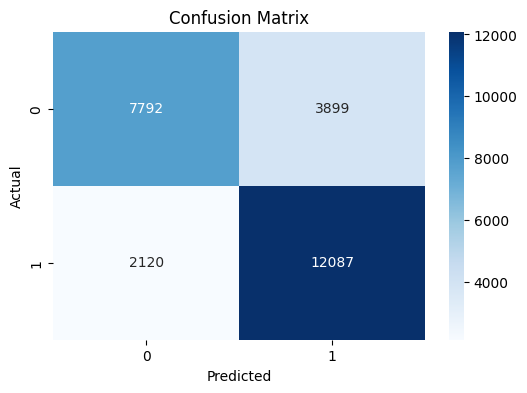

In [98]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(x_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [99]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 7792,  3899],
       [ 2120, 12087]], dtype=int64)

In [100]:
TN, FP, FN, TP = cm.ravel()

print("True Negative:", TN)
print("False Positive:", FP)
print("False Negative:", FN)
print("True Positive:", TP)

True Negative: 7792
False Positive: 3899
False Negative: 2120
True Positive: 12087


In [84]:
# chatgpt
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)

Inflight entertainment    0.197051
Seat comfort              0.132381
Ease of Online booking    0.074312
Online support            0.067765
Customer Type             0.047177
Food and drink            0.041117
On-board service          0.040856
Leg room service          0.038826
Flight Distance           0.036184
Online boarding           0.033121
dtype: float64

In [85]:
print("Train Accuracy:", rf.score(x_train, y_train))
print("Test Accuracy:", rf.score(x_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.9567534172522975


In [101]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score

In [102]:
from xgboost import XGBClassifier

xgb_model2 = XGBClassifier(n_estimators=100, random_state=42)

xgb_model2.fit(x_train, y_train)

xgb_pred2 = xgb_model2.predict(x_test)
xgb_prob2 = xgb_model2.predict_proba(x_test)[:,1]

xgb_auc2 = roc_auc_score(y_test, xgb_prob2)
xgb_f12 = f1_score(y_test, xgb_pred2)

print("XGBoost AUC after removing Experience:", xgb_auc2*100)
print("XGBoost F1 after removing Experience:", xgb_f12*100)

XGBoost AUC after removing Experience: 99.39733507711658
XGBoost F1 after removing Experience: 96.03827072997873


In [103]:
print("Train Accuracy:", xgb_model2.score(x_train, y_train))
print("Test Accuracy:", xgb_model2.score(x_test, y_test))

Train Accuracy: 0.9707787506395467
Test Accuracy: 0.9568306432929183


In [104]:
cm2 = confusion_matrix(y_test, xgb_pred2)
cm2

array([[11229,   462],
       [  656, 13551]], dtype=int64)

In [105]:
TN, FP, FN, TP = cm2.ravel()

print("True Negative:", TN)
print("False Positive:", FP)
print("False Negative:", FN)
print("True Positive:", TP)

True Negative: 11229
False Positive: 462
False Negative: 656
True Positive: 13551
